In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, roc_auc_score


# Import finalized feature data


In [2]:
data_file = "../processed_data/finalized_feature_data_2024-03-01_2026-05-02.csv"
feature_data = (
    pd.read_csv(data_file, parse_dates=["timestamp_utc"])
    .set_index("timestamp_utc")
    .sort_index()
)

# Keep the same interface as the TCN notebook.
feature_data["Day_of_week_sin"] = np.sin(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Day_of_week_cos"] = np.cos(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Month_sin"] = np.sin(2 * np.pi * feature_data["Month"] / 12)
feature_data["Month_cos"] = np.cos(2 * np.pi * feature_data["Month"] / 12)

observed_cols = [column for column in feature_data.columns if column.startswith("observed_")]
forecast_cols = [column for column in feature_data.columns if column.startswith("forecast_")]

feature_combined = feature_data.drop(columns=forecast_cols).copy()
forecast_data = feature_data[forecast_cols].copy()

display(feature_data.shape)
display(feature_combined.shape)
display(forecast_data.shape)


(18988, 63)

(18988, 43)

(18988, 20)

In [3]:
# Basic timestamp checks.
for name, df in {"feature_combined": feature_combined, "forecast_data": forecast_data}.items():
    if df.index.has_duplicates:
        raise ValueError(f"{name} has duplicated timestamps")

    hourly_steps = df.index.to_series().sort_values().diff().dropna()
    if not hourly_steps.eq(pd.Timedelta(hours=1)).all():
        raise ValueError(f"{name} is not continuous hourly data")


## Models:


In [4]:
# Config
lookback = 24
valid_start = pd.Timestamp("2025-07-01", tz="UTC")
test_start = pd.Timestamp("2025-12-01", tz="UTC")

hidden_dim = 64
num_layers = 1
dropout = 0.0
learning_rate = 0.001
weight_decay = 0.0
batch_size = 64
epochs = 10
patience = 5
seeds = [1, 2, 3]


In [5]:
# Model input tables. Target time is t; SMARD and price history end at t-24.
target = feature_combined["Negative_price"].astype(int).sort_index()

calendar_cols = [
    "Hour",
    "Day_of_week",
    "Month",
    "Is_weekend",
    "Hour_sin",
    "Hour_cos",
    "Day_of_week_sin",
    "Day_of_week_cos",
    "Month_sin",
    "Month_cos",
]

observed_cols = [c for c in feature_combined.columns if c.startswith("observed_")]
forecast_cols = [c for c in forecast_data.columns if c.startswith("forecast_")]
smard_input_cols = [
    c for c in feature_combined.columns
    if c not in calendar_cols + ["Negative_price"] + observed_cols
]

observed_weather = feature_combined[observed_cols].rename(columns=lambda c: c.replace("observed_", ""))
forecast_weather = forecast_data[forecast_cols].rename(columns=lambda c: c.replace("forecast_", ""))

if sorted(observed_weather.columns) != sorted(forecast_weather.columns):
    raise ValueError("Observed and forecast weather columns do not match after removing prefixes")

weather_cols = observed_weather.columns.tolist()
feature_cols = calendar_cols + smard_input_cols + weather_cols

past_raw = pd.concat(
    [feature_combined[calendar_cols], feature_combined[smard_input_cols], observed_weather],
    axis=1,
).sort_index()

forecast_future_raw = (
    feature_combined[calendar_cols]
    .join(forecast_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

oracle_future_raw = (
    feature_combined[calendar_cols]
    .join(observed_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

pd.DataFrame({
    "table": ["past_raw", "forecast_future_raw", "oracle_future_raw"],
    "shape": [past_raw.shape, forecast_future_raw.shape, oracle_future_raw.shape],
    "start": [past_raw.index.min(), forecast_future_raw.index.min(), oracle_future_raw.index.min()],
    "end": [past_raw.index.max(), forecast_future_raw.index.max(), oracle_future_raw.index.max()],
})


,table,shape,start,end
0,past_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
1,forecast_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
2,oracle_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00


In [6]:
# Scale with training-period statistics only.
train_rows = past_raw[past_raw.index < valid_start].reindex(columns=feature_cols)
feature_mean = train_rows.mean()
feature_std = train_rows.std().replace(0, 1).fillna(1)

def scale_features(df):
    return ((df.reindex(columns=feature_cols) - feature_mean) / feature_std).fillna(0.0)

past_scaled = scale_features(past_raw)
forecast_future_scaled = scale_features(forecast_future_raw)
oracle_future_scaled = scale_features(oracle_future_raw)


In [7]:
# Build sequences. Past part is t-(24+lookback-1)...t-24.
# If future_X is passed, append the deployable weather path t-23...t.
def build_sequences(X, y, future_X=None, lookback=24):
    Xs, ys, times = [], [], []

    X_values = X.to_numpy(dtype=np.float32)
    X_start = X.index.min()

    if future_X is not None:
        future_values = future_X.to_numpy(dtype=np.float32)
        future_start_time = future_X.index.min()

    for t in y.index:
        past_start = t - pd.Timedelta(hours=24 + lookback - 1)
        past_end = t - pd.Timedelta(hours=24)

        start_pos = int((past_start - X_start).total_seconds() // 3600)
        end_pos = int((past_end - X_start).total_seconds() // 3600) + 1

        if start_pos < 0 or end_pos > len(X_values):
            continue

        seq = X_values[start_pos:end_pos]
        if len(seq) != lookback:
            continue

        if future_X is not None:
            future_start = t - pd.Timedelta(hours=23)
            future_start_pos = int((future_start - future_start_time).total_seconds() // 3600)
            future_end_pos = int((t - future_start_time).total_seconds() // 3600) + 1

            if future_start_pos < 0 or future_end_pos > len(future_values):
                continue

            future_seq = future_values[future_start_pos:future_end_pos]
            if len(future_seq) != 24:
                continue

            seq = np.vstack([seq, future_seq])

        Xs.append(seq)
        ys.append(y.loc[t])
        times.append(t)

    return np.array(Xs), np.array(ys, dtype=np.float32), pd.DatetimeIndex(times)


In [8]:
# Build aligned datasets for one lookback value.
def split_sequences(X, y, times):
    train_mask = times < valid_start
    valid_mask = (times >= valid_start) & (times < test_start)
    test_mask = times >= test_start

    return {
        "X_train": X[train_mask],
        "y_train": y[train_mask],
        "X_valid": X[valid_mask],
        "y_valid": y[valid_mask],
        "X_test": X[test_mask],
        "y_test": y[test_mask],
    }


def keep_common_times(X, y, times, common_times):
    mask = times.isin(common_times)
    return X[mask], y[mask], times[mask]


def build_model_datasets(current_lookback):
    X_past, y_past, times_past = build_sequences(past_scaled, target, lookback=current_lookback)
    X_forecast, y_forecast, times_forecast = build_sequences(
        past_scaled, target, future_X=forecast_future_scaled, lookback=current_lookback
    )
    X_oracle, y_oracle, times_oracle = build_sequences(
        past_scaled, target, future_X=oracle_future_scaled, lookback=current_lookback
    )

    common_times = times_past.intersection(times_forecast).intersection(times_oracle).sort_values()

    X_past, y_past, times_past = keep_common_times(X_past, y_past, times_past, common_times)
    X_forecast, y_forecast, times_forecast = keep_common_times(X_forecast, y_forecast, times_forecast, common_times)
    X_oracle, y_oracle, times_oracle = keep_common_times(X_oracle, y_oracle, times_oracle, common_times)

    datasets = {
        "past_model": split_sequences(X_past, y_past, times_past),
        "forecast_model": split_sequences(X_forecast, y_forecast, times_forecast),
        "oracle_model": split_sequences(X_oracle, y_oracle, times_oracle),
    }

    summary = pd.DataFrame([
        {"model": "past_model", "lookback": current_lookback, "train": len(datasets["past_model"]["y_train"]), "valid": len(datasets["past_model"]["y_valid"]), "test": len(datasets["past_model"]["y_test"]), "sequence_shape": X_past.shape[1:]},
        {"model": "forecast_model", "lookback": current_lookback, "train": len(datasets["forecast_model"]["y_train"]), "valid": len(datasets["forecast_model"]["y_valid"]), "test": len(datasets["forecast_model"]["y_test"]), "sequence_shape": X_forecast.shape[1:]},
        {"model": "oracle_model", "lookback": current_lookback, "train": len(datasets["oracle_model"]["y_train"]), "valid": len(datasets["oracle_model"]["y_valid"]), "test": len(datasets["oracle_model"]["y_test"]), "sequence_shape": X_oracle.shape[1:]},
    ]).set_index("model")

    return datasets, summary, common_times


datasets, dataset_summary, common_times = build_model_datasets(lookback)
display(dataset_summary)
print("time span:", common_times.min(), "to", common_times.max())


,lookback,train,valid,test,sequence_shape
model,,,,,
past_model,24,11641,3672,3628,"(24, 42)"
forecast_model,24,11641,3672,3628,"(48, 42)"
oracle_model,24,11641,3672,3628,"(48, 42)"


time span: 2024-03-02 23:00:00+00:00 to 2026-05-01 03:00:00+00:00


## LSTM model


In [9]:
# LSTM structure
class CurtailmentLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        return self.fc(last_step).squeeze(-1)


In [10]:
# Dataloaders
def make_loader(X, y, shuffle):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [11]:
# Training, evaluation, and plotting helpers.
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return float(np.mean(losses))


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())

    return float(np.mean(losses))


def predict_probabilities(model, loader, device):
    model.eval()
    probabilities, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(device))
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(y_batch.numpy())

    return np.concatenate(probabilities), np.concatenate(targets)


def threshold_sweep(y_true, probabilities):
    thresholds = np.linspace(0.05, 0.95, 91)
    f1_scores = [f1_score(y_true, probabilities >= t, zero_division=0) for t in thresholds]
    best_index = int(np.argmax(f1_scores))
    return thresholds[best_index], f1_scores[best_index]


def plot_threshold_and_pr_curve(y_true, probabilities, threshold=None, title="LSTM validation"):
    precision, recall, pr_thresholds = precision_recall_curve(y_true, probabilities)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    best_index = int(np.argmax(f1_scores[:-1]))
    best_threshold = pr_thresholds[best_index]
    best_f1 = f1_scores[best_index]
    selected_threshold = best_threshold if threshold is None else threshold
    pr_auc = average_precision_score(y_true, probabilities)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(pr_thresholds, f1_scores[:-1])
    axes[0].axvline(selected_threshold, color="red", linestyle="--", label=f"threshold = {selected_threshold:.3f}")
    axes[0].set(xlabel="Probability threshold", ylabel="F1 score", title=f"{title}: F1 vs threshold")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(np.mean(y_true), color="gray", linestyle="--", label="Positive-rate baseline")
    axes[1].set(xlabel="Recall", ylabel="Precision", title=f"{title}: PR curve")
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return {"best_threshold": best_threshold, "best_f1": best_f1, "pr_auc": pr_auc}


In [12]:
# Run one model. The checkpoint is selected by valid PR-AUC.
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_random_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_experiment(
    name,
    data,
    hidden_dim_value=hidden_dim,
    num_layers_value=num_layers,
    dropout_value=dropout,
    learning_rate_value=learning_rate,
    weight_decay_value=weight_decay,
    seed=42,
    lookback_value=None,
    return_predictions=False,
    verbose=True,
):
    set_random_seed(seed)
    device = get_device()
    if verbose:
        print(f"Using device : {device}; seed={seed}")

    input_dim = data["X_train"].shape[2]
    model = CurtailmentLSTM(
        input_dim,
        hidden_dim=hidden_dim_value,
        num_layers=num_layers_value,
        dropout=dropout_value,
    ).to(device)

    num_pos = data["y_train"].sum()
    num_neg = len(data["y_train"]) - num_pos
    pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate_value, weight_decay=weight_decay_value)

    train_loader = make_loader(data["X_train"], data["y_train"], shuffle=True)
    valid_loader = make_loader(data["X_valid"], data["y_valid"], shuffle=False)
    test_loader = make_loader(data["X_test"], data["y_test"], shuffle=False)

    best_state = None
    best_epoch = 0
    best_valid_pr_auc = -np.inf
    best_valid_f1_seen = -np.inf
    best_valid_f1_threshold = 0.5
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss = evaluate_loss(model, valid_loader, criterion, device)
        valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
        valid_pr_auc = average_precision_score(valid_true, valid_prob)
        threshold, valid_f1 = threshold_sweep(valid_true, valid_prob)

        if valid_f1 > best_valid_f1_seen:
            best_valid_f1_seen = valid_f1
            best_valid_f1_threshold = threshold

        if valid_pr_auc > best_valid_pr_auc:
            best_valid_pr_auc = valid_pr_auc
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"{name} epoch {epoch + 1:02d}: "
                f"train_loss={train_loss:.4f}, "
                f"valid_loss={valid_loss:.4f}, "
                f"valid_F1={valid_f1:.4f}, "
                f"threshold={threshold:.2f}, "
                f"valid_PR_AUC={valid_pr_auc:.4f}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch + 1:02d}; best valid_PR_AUC={best_valid_pr_auc:.4f}")
            break

    model.load_state_dict(best_state)

    valid_prob, valid_true = predict_probabilities(model, valid_loader, device)
    selected_threshold, selected_valid_f1 = threshold_sweep(valid_true, valid_prob)
    test_prob, test_true = predict_probabilities(model, test_loader, device)

    result = {
        "model": name,
        "seed": seed,
        "lookback": lookback if lookback_value is None else lookback_value,
        "hidden_dim": hidden_dim_value,
        "num_layers": num_layers_value,
        "dropout": dropout_value,
        "learning_rate": learning_rate_value,
        "weight_decay": weight_decay_value,
        "best_epoch_by_PR_AUC": best_epoch,
        "train_size": len(data["y_train"]),
        "valid_size": len(data["y_valid"]),
        "test_size": len(data["y_test"]),
        "sequence_shape": str(data["X_train"].shape[1:]),
        "valid_PR_AUC": average_precision_score(valid_true, valid_prob),
        "selected_valid_F1": selected_valid_f1,
        "selected_threshold": selected_threshold,
        "best_valid_F1_seen": best_valid_f1_seen,
        "best_valid_F1_threshold": best_valid_f1_threshold,
        "test_PR_AUC_at_checkpoint": average_precision_score(test_true, test_prob),
        "test_ROC_AUC_at_checkpoint": roc_auc_score(test_true, test_prob),
        "test_F1_at_validation_threshold": f1_score(test_true, test_prob >= selected_threshold, zero_division=0),
    }
    if return_predictions:
        result["valid_true"] = valid_true
        result["valid_prob"] = valid_prob
        result["test_true"] = test_true
        result["test_prob"] = test_prob
    return result


In [13]:
# Run all three models and average over three seeds.
seed_rows = []

for seed in seeds:
    for model_name, model_data in datasets.items():
        seed_rows.append(
            run_experiment(
                model_name,
                model_data,
                seed=seed,
                lookback_value=lookback,
                verbose=False,
            )
        )

seed_results_df = pd.DataFrame(seed_rows)

results_df = (
    seed_results_df
    .groupby(["model", "lookback", "hidden_dim", "num_layers", "dropout", "learning_rate", "weight_decay", "sequence_shape"], sort=False)
    .agg(
        valid_PR_AUC=("valid_PR_AUC", "mean"),
        selected_valid_F1=("selected_valid_F1", "mean"),
        selected_threshold_mean=("selected_threshold", "mean"),
        valid_PR_AUC_std=("valid_PR_AUC", "std"),
        selected_valid_F1_std=("selected_valid_F1", "std"),
        train_size=("train_size", "first"),
        valid_size=("valid_size", "first"),
        test_size=("test_size", "first"),
    )
    .reset_index()
    .sort_values(["selected_valid_F1", "valid_PR_AUC"], ascending=False)
    .reset_index(drop=True)
)

display(results_df)


,model,lookback,hidden_dim,num_layers,dropout,learning_rate,weight_decay,sequence_shape,valid_PR_AUC,selected_valid_F1,selected_threshold_mean,valid_PR_AUC_std,selected_valid_F1_std,train_size,valid_size,test_size
0,forecast_model,24,64,1,0.0,0.001,0.0,"(48, 42)",0.608600,0.597177,0.866667,0.030997,0.026010,11641,3672,3628
1,oracle_model,24,64,1,0.0,0.001,0.0,"(48, 42)",0.575346,0.578730,0.876667,0.069035,0.047093,11641,3672,3628
2,past_model,24,64,1,0.0,0.001,0.0,"(24, 42)",0.388516,0.429672,0.896667,0.019634,0.009582,11641,3672,3628


## Tuning


In [14]:
tuning_seeds = [1, 2, 3]
lookback_values = [24, 48, 72, 168]
hidden_dim_options = [32, 64]
learning_rate_options = [0.001, 0.0005]
weight_decay_options = [0.0, 1e-4]

tuning_rows = []
tuning_predictions = {}

for current_lookback in lookback_values:
    lookback = current_lookback
    datasets, dataset_summary, common_times = build_model_datasets(lookback)
    print("lookback =", lookback)

    for hidden_dim_value in hidden_dim_options:
        for learning_rate_value in learning_rate_options:
            for weight_decay_value in weight_decay_options:
                combo_rows = []
                print(
                    f"  tuning hidden_dim={hidden_dim_value}, "
                    f"lr={learning_rate_value}, weight_decay={weight_decay_value} "
                    f"over seeds={tuning_seeds}"
                )

                for seed in tuning_seeds:
                    result = run_experiment(
                        "forecast_model",
                        datasets["forecast_model"],
                        hidden_dim_value=hidden_dim_value,
                        num_layers_value=num_layers,
                        dropout_value=dropout,
                        learning_rate_value=learning_rate_value,
                        weight_decay_value=weight_decay_value,
                        seed=seed,
                        lookback_value=current_lookback,
                        return_predictions=True,
                        verbose=False,
                    )
                    prediction_key = (current_lookback, hidden_dim_value, learning_rate_value, weight_decay_value, seed)
                    tuning_predictions[prediction_key] = {
                        "valid_true": result.pop("valid_true"),
                        "valid_prob": result.pop("valid_prob"),
                        "test_true": result.pop("test_true"),
                        "test_prob": result.pop("test_prob"),
                    }
                    tuning_rows.append(result)
                    combo_rows.append(result)

                combo_df = pd.DataFrame(combo_rows)
                print(
                    "    3-seed mean: "
                    f"selected_valid_F1={combo_df['selected_valid_F1'].mean():.4f} "
                    f"(+/- {combo_df['selected_valid_F1'].std():.4f}), "
                    f"valid_PR_AUC={combo_df['valid_PR_AUC'].mean():.4f} "
                    f"(+/- {combo_df['valid_PR_AUC'].std():.4f})"
                )


tuning_seed_results_df = pd.DataFrame(tuning_rows)

tuning_summary_df = (
    tuning_seed_results_df
    .groupby(["lookback", "hidden_dim", "num_layers", "dropout", "learning_rate", "weight_decay", "sequence_shape"], sort=False)
    .agg(
        valid_PR_AUC=("valid_PR_AUC", "mean"),
        selected_valid_F1=("selected_valid_F1", "mean"),
        selected_threshold_mean=("selected_threshold", "mean"),
        valid_PR_AUC_std=("valid_PR_AUC", "std"),
        selected_valid_F1_std=("selected_valid_F1", "std"),
        seed_count=("seed", "nunique"),
        train_size=("train_size", "first"),
        valid_size=("valid_size", "first"),
        test_size=("test_size", "first"),
    )
    .reset_index()
    .sort_values(["selected_valid_F1", "valid_PR_AUC"], ascending=False)
    .reset_index(drop=True)
)

best_tuning_row = tuning_summary_df.iloc[0]
best_lookback = int(best_tuning_row["lookback"])
best_hidden_dim = int(best_tuning_row["hidden_dim"])
best_learning_rate = float(best_tuning_row["learning_rate"])
best_weight_decay = float(best_tuning_row["weight_decay"])
best_validation_threshold = float(best_tuning_row["selected_threshold_mean"])

print("Best tuning parameters selected by 3-seed mean selected_valid_F1")
print({
    "lookback": best_lookback,
    "hidden_dim": best_hidden_dim,
    "learning_rate": best_learning_rate,
    "weight_decay": best_weight_decay,
    "selected_valid_F1": best_tuning_row["selected_valid_F1"],
    "valid_PR_AUC": best_tuning_row["valid_PR_AUC"],
    "validation_threshold_mean": best_validation_threshold,
})

display(tuning_summary_df)


lookback = 24
  tuning hidden_dim=32, lr=0.001, weight_decay=0.0 over seeds=[1, 2, 3]
    3-seed mean: selected_valid_F1=0.6131 (+/- 0.0122), valid_PR_AUC=0.6282 (+/- 0.0119)
  tuning hidden_dim=32, lr=0.001, weight_decay=0.0001 over seeds=[1, 2, 3]
    3-seed mean: selected_valid_F1=0.6127 (+/- 0.0127), valid_PR_AUC=0.6276 (+/- 0.0109)
  tuning hidden_dim=32, lr=0.0005, weight_decay=0.0 over seeds=[1, 2, 3]
    3-seed mean: selected_valid_F1=0.6255 (+/- 0.0237), valid_PR_AUC=0.6411 (+/- 0.0196)
  tuning hidden_dim=32, lr=0.0005, weight_decay=0.0001 over seeds=[1, 2, 3]
    3-seed mean: selected_valid_F1=0.6240 (+/- 0.0250), valid_PR_AUC=0.6429 (+/- 0.0224)
  tuning hidden_dim=64, lr=0.001, weight_decay=0.0 over seeds=[1, 2, 3]
    3-seed mean: selected_valid_F1=0.5972 (+/- 0.0260), valid_PR_AUC=0.6086 (+/- 0.0310)
  tuning hidden_dim=64, lr=0.001, weight_decay=0.0001 over seeds=[1, 2, 3]
    3-seed mean: selected_valid_F1=0.5959 (+/- 0.0235), valid_PR_AUC=0.6116 (+/- 0.0337)
  tuning 

,lookback,hidden_dim,num_layers,dropout,learning_rate,weight_decay,sequence_shape,valid_PR_AUC,selected_valid_F1,selected_threshold_mean,valid_PR_AUC_std,selected_valid_F1_std,seed_count,train_size,valid_size,test_size
0,72,32,1,0.0,0.0010,0.0001,"(96, 42)",0.662030,0.627804,0.863333,0.027195,0.021274,3,11593,3672,3628
1,72,32,1,0.0,0.0010,0.0000,"(96, 42)",0.661918,0.626181,0.863333,0.027080,0.019701,3,11593,3672,3628
2,24,32,1,0.0,0.0005,0.0000,"(48, 42)",0.641107,0.625464,0.890000,0.019638,0.023716,3,11641,3672,3628
3,24,32,1,0.0,0.0005,0.0001,"(48, 42)",0.642869,0.623986,0.890000,0.022366,0.024989,3,11641,3672,3628
4,168,32,1,0.0,0.0010,0.0000,"(192, 42)",0.644880,0.623946,0.883333,0.011520,0.003509,3,11497,3672,3628
5,48,32,1,0.0,0.0005,0.0001,"(72, 42)",0.650117,0.622968,0.876667,0.023950,0.022573,3,11617,3672,3628
6,48,32,1,0.0,0.0005,0.0000,"(72, 42)",0.649380,0.622594,0.876667,0.023587,0.023366,3,11617,3672,3628
7,168,32,1,0.0,0.0010,0.0001,"(192, 42)",0.646155,0.621944,0.883333,0.010338,0.007416,3,11497,3672,3628
8,168,32,1,0.0,0.0005,0.0000,"(192, 42)",0.651659,0.620650,0.860000,0.011872,0.017013,3,11497,3672,3628
9,168,32,1,0.0,0.0005,0.0001,"(192, 42)",0.651349,0.619182,0.856667,0.011418,0.016276,3,11497,3672,3628


## Best Tuning Diagnostics


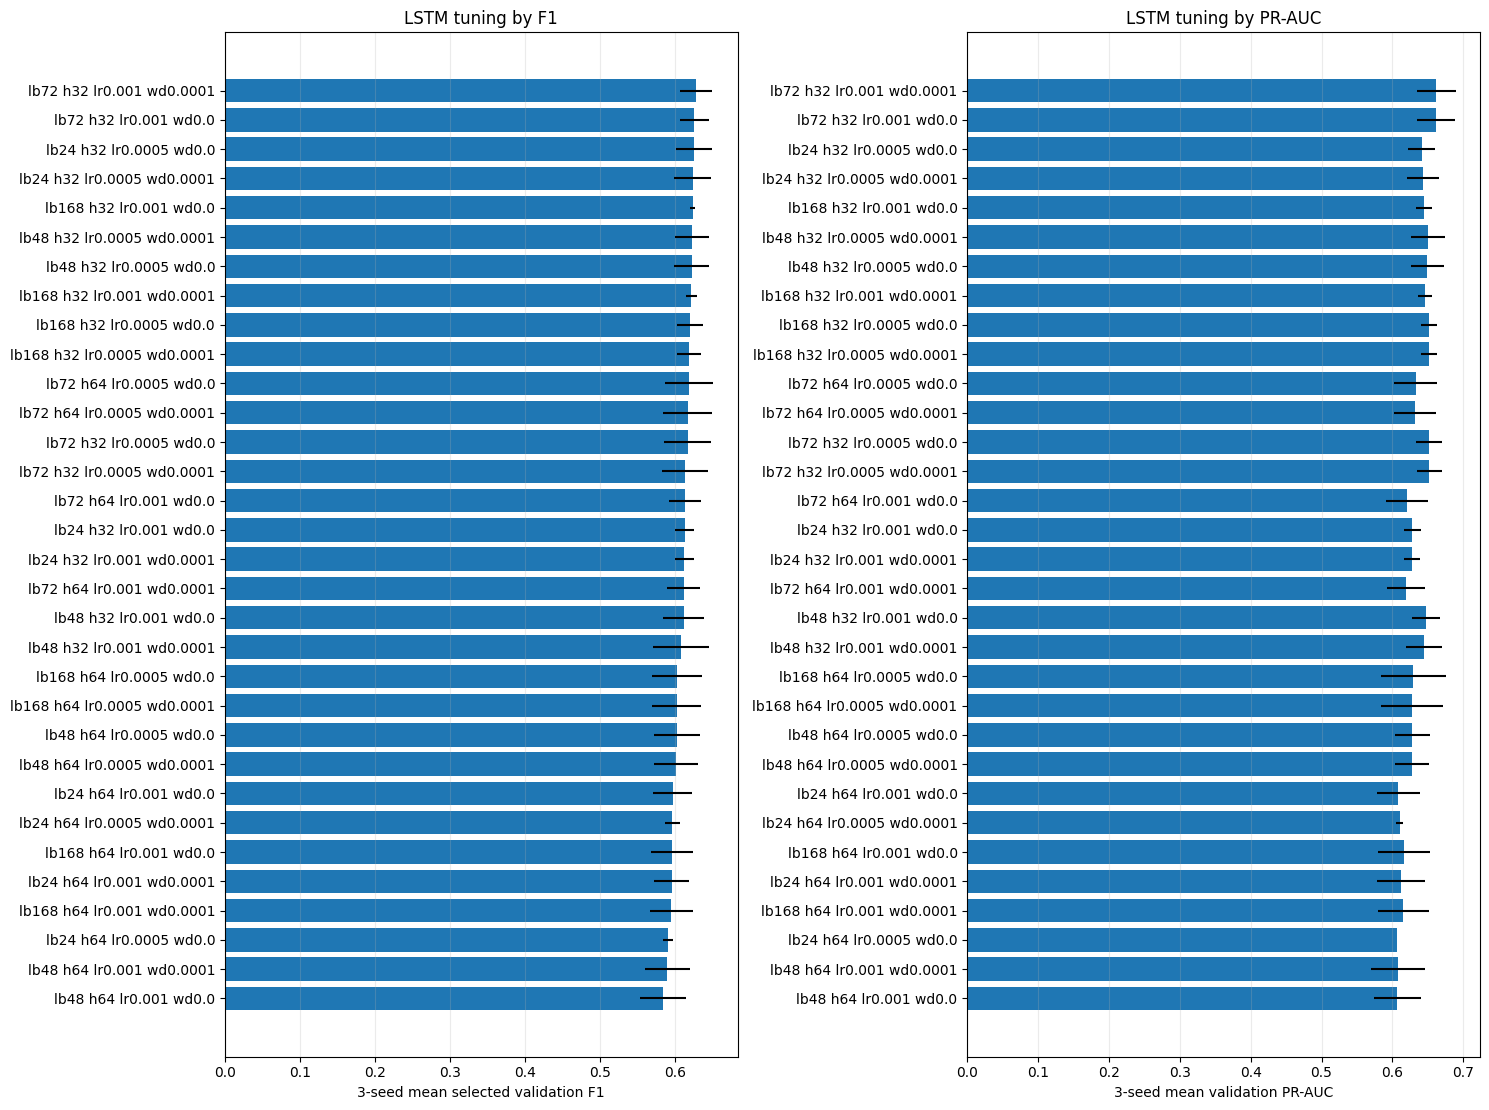

Diagnostic combo selected by 3-seed mean valid_PR_AUC


,lookback,hidden_dim,num_layers,dropout,learning_rate,weight_decay,sequence_shape,valid_PR_AUC,selected_valid_F1,selected_threshold_mean,valid_PR_AUC_std,selected_valid_F1_std,seed_count,train_size,valid_size,test_size
0,72,32,1,0.0,0.001,0.0001,"(96, 42)",0.66203,0.627804,0.863333,0.027195,0.021274,3,11593,3672,3628


Plotting validation curves for seed=1


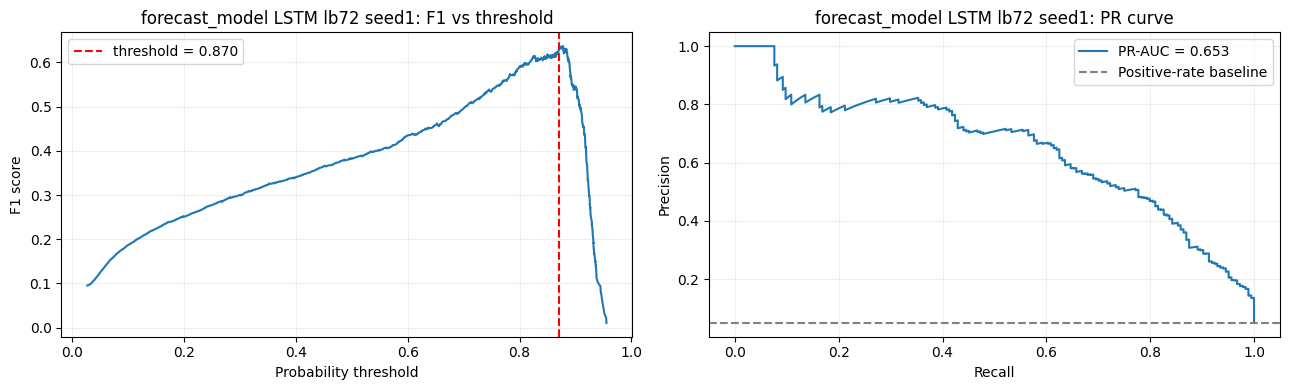

,best_threshold,best_f1,pr_auc
0,0.876954,0.63662,0.653218


In [15]:
plot_tuning = tuning_summary_df.copy()
plot_tuning["label"] = (
    "lb" + plot_tuning["lookback"].astype(str)
    + " h" + plot_tuning["hidden_dim"].astype(str)
    + " lr" + plot_tuning["learning_rate"].astype(str)
    + " wd" + plot_tuning["weight_decay"].astype(str)
)
plot_tuning = plot_tuning.sort_values("selected_valid_F1", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.35 * len(plot_tuning))))
axes[0].barh(plot_tuning["label"], plot_tuning["selected_valid_F1"], xerr=plot_tuning["selected_valid_F1_std"].fillna(0))
axes[0].set(xlabel="3-seed mean selected validation F1", title="LSTM tuning by F1")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(plot_tuning["label"], plot_tuning["valid_PR_AUC"], xerr=plot_tuning["valid_PR_AUC_std"].fillna(0))
axes[1].set(xlabel="3-seed mean validation PR-AUC", title="LSTM tuning by PR-AUC")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

best_pr_auc_row = tuning_summary_df.sort_values(["valid_PR_AUC", "selected_valid_F1"], ascending=False).iloc[0]
diagnostic_lookback = int(best_pr_auc_row["lookback"])
diagnostic_hidden_dim = int(best_pr_auc_row["hidden_dim"])
diagnostic_learning_rate = float(best_pr_auc_row["learning_rate"])
diagnostic_weight_decay = float(best_pr_auc_row["weight_decay"])
diagnostic_seed = 1

diagnostic_seed_row = tuning_seed_results_df[
    (tuning_seed_results_df["lookback"] == diagnostic_lookback)
    & (tuning_seed_results_df["hidden_dim"] == diagnostic_hidden_dim)
    & (tuning_seed_results_df["learning_rate"] == diagnostic_learning_rate)
    & (tuning_seed_results_df["weight_decay"] == diagnostic_weight_decay)
    & (tuning_seed_results_df["seed"] == diagnostic_seed)
].iloc[0]

best_prediction_key = (
    diagnostic_lookback,
    diagnostic_hidden_dim,
    diagnostic_learning_rate,
    diagnostic_weight_decay,
    diagnostic_seed,
)
best_prediction = tuning_predictions[best_prediction_key]

print("Diagnostic combo selected by 3-seed mean valid_PR_AUC")
display(pd.DataFrame([best_pr_auc_row]))
print(f"Plotting validation curves for seed={diagnostic_seed}")
validation_curve_summary = plot_threshold_and_pr_curve(
    best_prediction["valid_true"],
    best_prediction["valid_prob"],
    threshold=float(diagnostic_seed_row["selected_threshold"]),
    title=f"forecast_model LSTM lb{diagnostic_lookback} seed{diagnostic_seed}",
)
display(pd.DataFrame([validation_curve_summary]))


## Final Train+Validation Fit and Test Evaluation


Final forecast_model test results after training on train+validation


,model,seed,lookback,hidden_dim,learning_rate,weight_decay,threshold_from_validation,train_valid_size,test_size,test_PR_AUC,test_ROC_AUC,test_F1_at_validation_threshold,test_positive_rate,train_loss_last
0,forecast_model_final,1,72,32,0.001,0.0001,0.863333,15265,3628,0.834148,0.987588,0.616601,0.04548,0.132939
1,forecast_model_final,2,72,32,0.001,0.0001,0.863333,15265,3628,0.759041,0.984342,0.636704,0.04548,0.117664
2,forecast_model_final,3,72,32,0.001,0.0001,0.863333,15265,3628,0.871593,0.990639,0.694340,0.04548,0.139626


,mean,std
test_PR_AUC,0.821594,0.057317
test_ROC_AUC,0.987523,0.003149
test_F1_at_validation_threshold,0.649215,0.040351
test_positive_rate,0.045480,NaN


Plotting test curves for final forecast_model seed=1


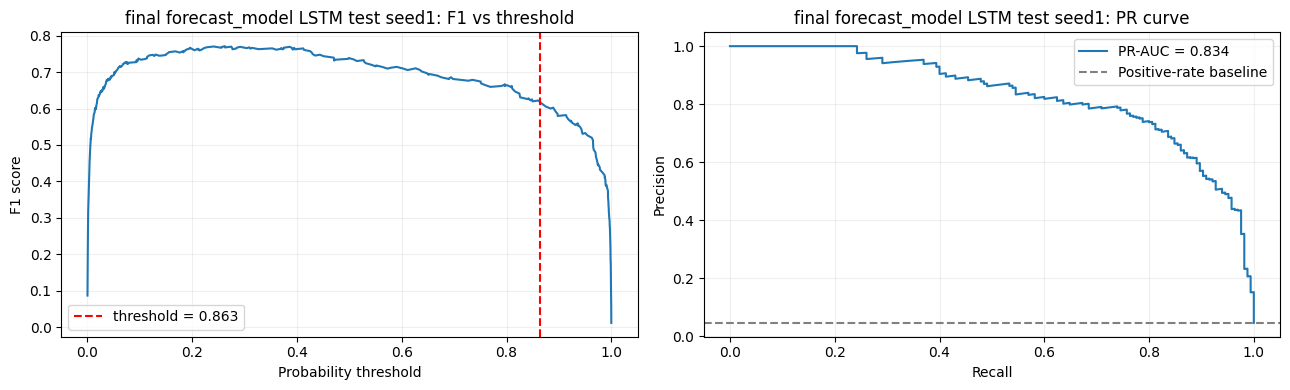

,best_threshold,best_f1,pr_auc
0,0.262527,0.771014,0.834148


In [16]:
def train_final_forecast_model(data, seed, threshold):
    set_random_seed(seed)
    device = get_device()
    X_dev = np.concatenate([data["X_train"], data["X_valid"]], axis=0)
    y_dev = np.concatenate([data["y_train"], data["y_valid"]], axis=0)

    input_dim = X_dev.shape[2]
    model = CurtailmentLSTM(
        input_dim,
        hidden_dim=best_hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    num_pos = y_dev.sum()
    num_neg = len(y_dev) - num_pos
    pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)

    dev_loader = make_loader(X_dev, y_dev, shuffle=True)
    test_loader = make_loader(data["X_test"], data["y_test"], shuffle=False)

    train_losses = []
    for epoch in range(epochs):
        train_losses.append(train_epoch(model, dev_loader, criterion, optimizer, device))

    test_prob, test_true = predict_probabilities(model, test_loader, device)
    return {
        "model": "forecast_model_final",
        "seed": seed,
        "lookback": best_lookback,
        "hidden_dim": best_hidden_dim,
        "learning_rate": best_learning_rate,
        "weight_decay": best_weight_decay,
        "threshold_from_validation": threshold,
        "train_valid_size": len(y_dev),
        "test_size": len(test_true),
        "test_PR_AUC": average_precision_score(test_true, test_prob),
        "test_ROC_AUC": roc_auc_score(test_true, test_prob),
        "test_F1_at_validation_threshold": f1_score(test_true, test_prob >= threshold, zero_division=0),
        "test_positive_rate": test_true.mean(),
        "test_true": test_true,
        "test_prob": test_prob,
        "train_loss_last": train_losses[-1],
    }


lookback = best_lookback
datasets, dataset_summary, common_times = build_model_datasets(best_lookback)
final_forecast_data = datasets["forecast_model"]

final_results = []
final_predictions = {}
for seed in tuning_seeds:
    result = train_final_forecast_model(
        final_forecast_data,
        seed=seed,
        threshold=best_validation_threshold,
    )
    final_predictions[seed] = {
        "test_true": result.pop("test_true"),
        "test_prob": result.pop("test_prob"),
    }
    final_results.append(result)

final_test_results_df = pd.DataFrame(final_results)
final_test_summary = final_test_results_df.agg({
    "test_PR_AUC": ["mean", "std"],
    "test_ROC_AUC": ["mean", "std"],
    "test_F1_at_validation_threshold": ["mean", "std"],
    "test_positive_rate": ["mean"],
}).T

print("Final forecast_model test results after training on train+validation")
display(final_test_results_df)
display(final_test_summary)

plot_seed = 1
plot_prediction = final_predictions[plot_seed]
print(f"Plotting test curves for final forecast_model seed={plot_seed}")
test_curve_summary = plot_threshold_and_pr_curve(
    plot_prediction["test_true"],
    plot_prediction["test_prob"],
    threshold=best_validation_threshold,
    title=f"final forecast_model LSTM test seed{plot_seed}",
)
display(pd.DataFrame([test_curve_summary]))
